# Modeling type of charts to represents concrete degrad

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [2]:
def momento_resistente_secao_sem_cor(a_s: float, b_w: float, h: float, f_ck: float, f_yk: float = 500000, gamma_s: float = 1.15, gamma_c: float = 1.40) -> float:
    """
    Calcula o momento resistente para vigas de concreto armado.

    Args:
        a_s (float): Área da armadura longitudinal (mm²)
        b_w (float): Largura da seção transversal (mm)
        h (float): Altura total da seção transversal (mm)
        f_ck (float): Resistência característica à compressão do concreto (kPa)
        f_yk (float): Resistência característica do aço (kPa). Padrão: 500000
        gamma_s (float): Fator de segurança do aço. Padrão: 1.15
        gamma_c (float): Fator de segurança do concreto. Padrão: 1.40

    Returns:
        m_rd: valor do momento resistente limite utilizando armadura simples (N.mm)
    """

    """
    Transforms a vector of random variables from the X space to the Y space.

    :param x: Random variables in the X space.
    :param dneq1: D^-1 matrix.
    :param mu_neq: Mean matrix.
    
    :return: output [0] = Probability of failure values for each indicator function, 
                output[1] = beta_df: Reliability index values for each indicator function.
    """

    # Temporary conversion of f_ck to MPa to determine coefficients
    f_ck /= 1E3  # in MPa

    if f_ck > 50:
        lambdaa = 0.80 - ((f_ck - 50) / 400)
        alpha_c = (1.00 - ((f_ck - 50) / 200)) * 0.85
    else:
        lambdaa = 0.80
        alpha_c = 0.85

    f_ck *= 1E3
    # Convert f_ck back to kPa and calculate f_cd (design compressive strength)
    f_cd = f_ck / gamma_c

    # Effective depth of the section
    d = h * 0.90

    # Design yield strength of steel
    f_yd = f_yk / gamma_s

    # Depth of the neutral axis
    x = (a_s * f_yd) / (f_cd * b_w * alpha_c * lambdaa)

    # Calculation of the ultimate resisting moment
    m_rd = a_s * f_yd * (d - 0.5 * lambdaa * x)

    return m_rd


## Modeling

Load dataset

In [3]:
# File path to the Excel spreadsheet
file_path = r'final_df_tempo_limite_lhspequeno.xlsx'

# Read the entire Excel file
full_df = pd.read_excel(file_path)

# Select the first row (useful for initial testing or verification)
df = full_df.head(1)

# Display the selected DataFrame
print(df)


    b_w    h   f_ck      m_rd      m_gk      m_qk       a_s       time
0  0.14  0.3  20000  9.836582  6.323517  0.702613  0.000076  47.180765


In [4]:
# Define the number os samples
n = 50000
# Time steps (e.g., years or inspection intervals)
x = np.arange(0, 101, 20)

In [ ]:
# Initialize lists to store results for resisting moment and degraded steel area
results_mr = []
results_ms = []
results_as = []
results_g = []

# Loop over each row in the DataFrame
for i, row in df.iterrows():
    # Extract input parameters from the DataFrame
    b_w = row['b_w']                # Section width (cm)
    h = row['h']                    # Section height (cm)
    f_ck = row['f_ck']              # Concrete compressive strength (kPa)
    f_yk = 500E3                    # Characteristic steel yield strength (kPa)
    m_gk = row['m_gk']              # Dead load moment (N·cm)
    m_qk = row['m_qk']              # Live load moment (N·cm)
    a_s_initial = row['a_s']        # Initial steel area (cm²)

    # Monte Carlo simulations
    for j in range(n):
        m_r_list = []             # List to store resisting moments over time
        a_s_list = []             # List to store degraded steel area over time
        m_s_list = []           # List to store dead load moments over time
        g_list = []           # List to store live load moments over time

        # Sample from normal distributions for concrete strength, steel yield strength, and dead load moment
        f_ck_sample = np.random.normal(1.22 * f_ck, 0.12 * 1.22 * f_ck)
        f_yk_sample = np.random.normal(1.22 * f_yk, 0.05 * 1.22 * f_yk)
        m_gk_sample = np.random.normal(1.06 * m_gk, 0.12 * 1.06 * m_gk)

        # Loop through each time step (e.g., years)
        for k in x:
            # Sample from a Gumbel distribution for live load moment
            m_qk_sample = np.random.gumbel(0.21 * m_qk, 0.21 * 0.76 * m_qk) # Aqui deveria ser a gamma

            # Profundidade de carbonatação
            y_carb.append(profundidade_carbonatacao_possan(k_c, k_fc,  f_ck/1000,
                                                       i, ad, k_ad, co2, k_co2,
                                                       ur/100, k_rh, k_ce))
            
            print('profundidade de carbonatacao com 100 anos (m): ', y_carb[-1])

            if y_carb > cobrimento:

                # Tempo de início da corrosão
                t_cor_0, _, _= tempo_iniciacao_corrosao(k_c, k_fc, f_ck,
                                       ad, k_ad, k_co2,
                                       ur,k_rh, k_ce, cob, 2023)
                print('tempo de inicio de corrosao (anos): ', t_cor_0)

                # Índice de corrosão
                i_cor20 = 1E-5
                temp = 40
                i_cor = indice_corrosao_(i_cor20, temp)
                print('indice de corrosao (microA/cm2): ', i_cor)

                # Momento resistente com corrosão
                t = 50
                t_i_cor = 32
                m_rd, c_f, d_novo, d = momento_resistente_com_corrosao_azad_algohi(d_barras, n_barras, f_ck, f_yk,
                                                                                b_w, d, gamma_c, gamma_s,
                                                                                i_cor20, temp, t, t_i_cor)
                print('diametro d novo: ', d_novo, 'c_f: ', c_f, 'momento resistente com corrosao (kN.m): ', m_rd)

            else:

                # Momento resistente sem corrosão
                m_r = momento_resistente_secao_sem_cor(a_s, b_w, h, f_ck_sample, f_yk_sample, gamma_s=1.00, gamma_c=1.00)   


            # # Define degradation factor for steel area
            # if k < 39:
            #     degradation_factor = 1.0  # No degradation before year 39
            # else:
            #     a_d = 1.0
            #     b_d = 0.000055
            #     degradation_factor = a_d * (1 - b_d * k**2)

            # # Calculate degraded steel area
            # a_s_degraded = a_s_initial * degradation_factor

            # # Compute resisting moment using custom function
            # m_r = momento_resistente_secao_sem_cor(a_s_degraded, b_w, h, f_ck_sample, f_yk_sample, gamma_s=1.00, gamma_c=1.00)

            # Store results at this time step
            m_r_list.append(m_r)
            m_s_list.append(m_gk_sample + m_qk_sample)
            a_s_list.append(a_s_degraded)
            g_list.append(m_r - (m_gk_sample + m_qk_sample))

        # Store time series for this simulation
        results_mr.append(m_r_list)
        results_ms.append(m_s_list)
        results_as.append(a_s_list)
        results_g.append(g_list)

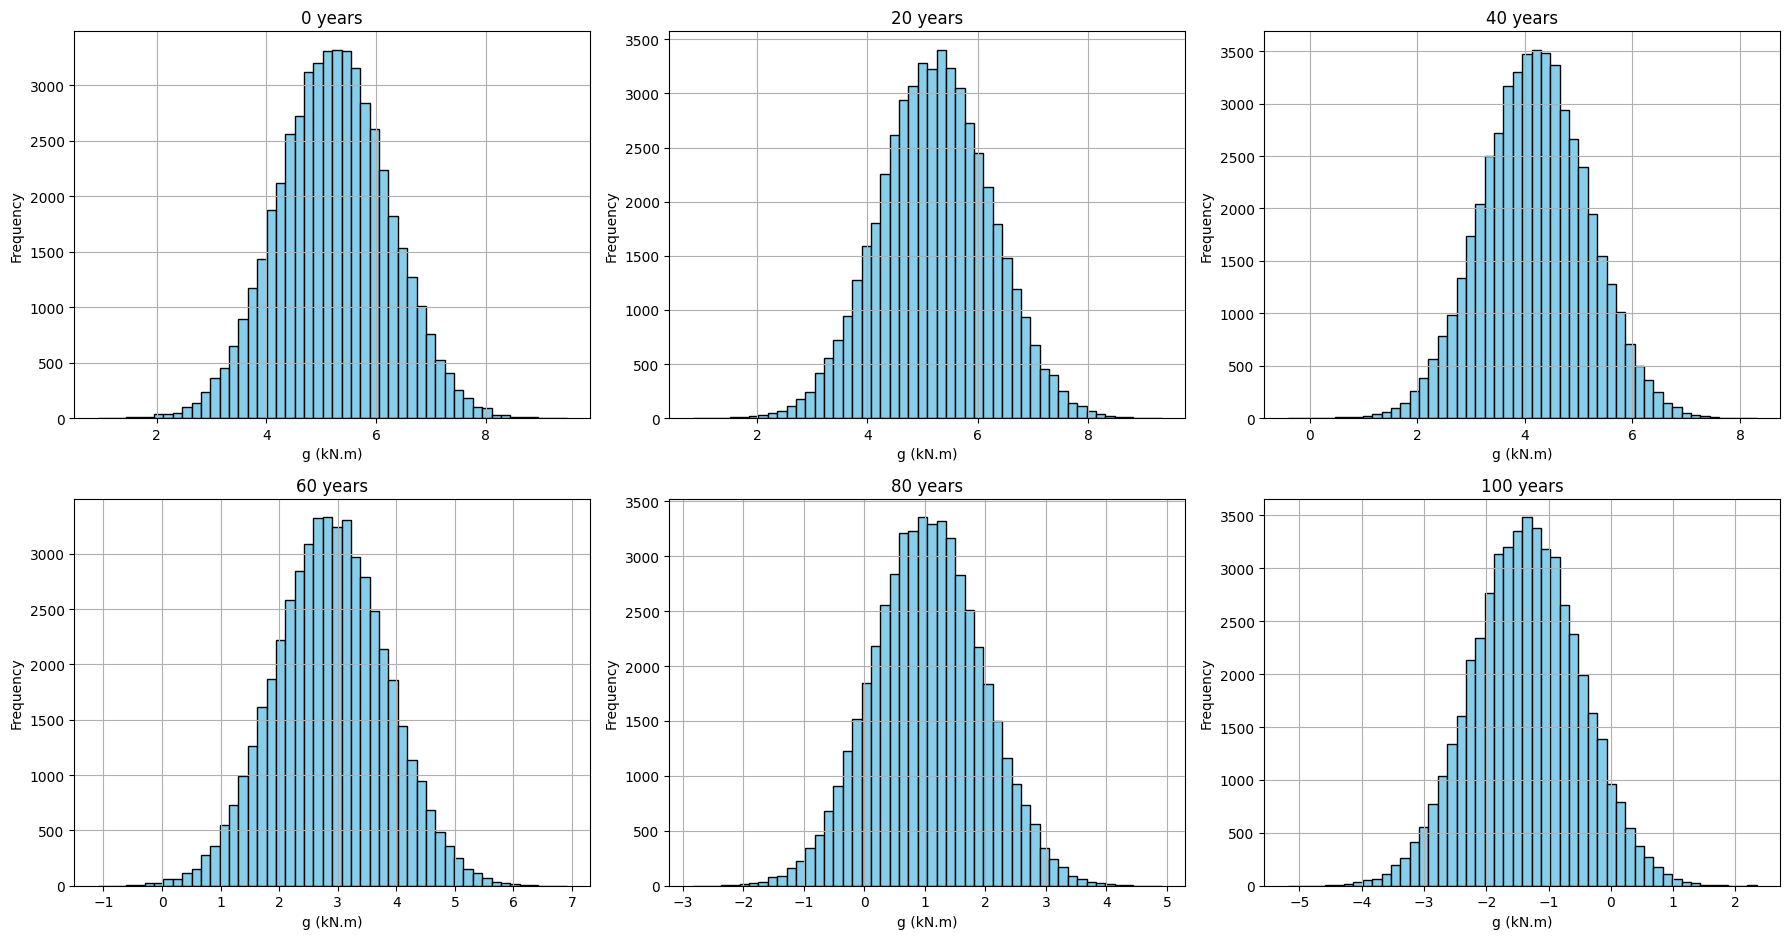

In [17]:
# List of times corresponding to indices of each value in g_list
times = [0, 20, 40, 60, 80, 100]

# Create a dictionary to store g values (m_r - m_gk - m_qk) separated by time
t_dict = {time: [] for time in times}

# Iterate over each simulation and separate the values by time
for g_list in results_g:
    for idx, time in enumerate(times):
        t_dict[time].append(g_list[idx])

# Create separate lists for each time to work outside the dictionary if needed
t_0 = t_dict[0]
t_20 = t_dict[20]
t_40 = t_dict[40]
t_60 = t_dict[60]
t_80 = t_dict[80]
t_100 = t_dict[100]

# Group the lists in a main list to facilitate plotting loop
t_lists = [t_0, t_20, t_40, t_60, t_80, t_100]

# Define times again for joint iteration with the lists
times = [0, 20, 40, 60, 80, 100]

# Create figure and axes for 6 subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# For each list and respective time, plot on the corresponding subplot
for idx, (t_values, time) in enumerate(zip(t_lists, times)):
    ax = axes[idx // 3, idx % 3]  # Calculate subplot position (row, column)
    ax.hist(t_values, bins=50, color='skyblue', edgecolor='black')
    ax.set_title(f'{time} years')
    ax.set_xlabel('g (kN.m)')
    ax.set_ylabel('Frequency')
    ax.grid(True)

# Adjust layout to avoid overlapping texts and leave space for main title
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show the figure with histograms
plt.show()



Plots

- chart resistent bending moment

In [ ]:
# Plotting resistant moment curves for each simulation
plt.figure(figsize=(6, 4))  # Set figure size (width x height in inches)

for m_r_curve in results_mr:    
    # Plot each resistance curve
     plt.scatter(list(x), m_r_curve, marker='o', linestyle='-', color='gray', alpha=0.3)

# Plot formatting
font = 11
plt.xlabel('Time (years)', fontsize=font)
plt.ylabel('Moment capacity (kN·m)', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(list(x))
plt.tight_layout()
plt.savefig('moment_cap_curves.png', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


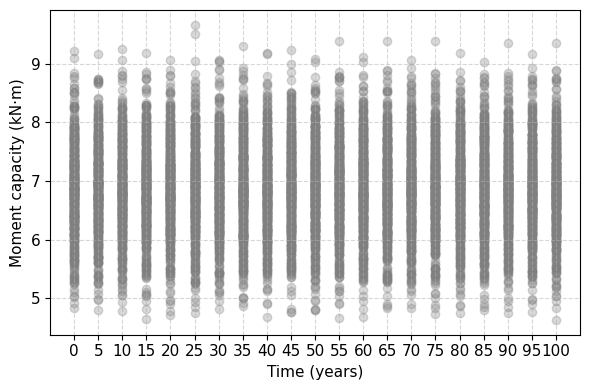

In [ ]:
# Plotting resistant moment curves for each simulation
plt.figure(figsize=(6, 4))  # Set figure size (width x height in inches)

for m_s_curve in results_ms:
    # Plot each resistance curve
    plt.scatter(list(x), m_s_curve, marker='o', linestyle='-', color='gray', alpha=0.3)

# Plot formatting
font = 11
plt.xlabel('Time (years)', fontsize=font)
plt.ylabel('Moment demand (kN·m)', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(list(x))
plt.tight_layout()
plt.savefig('moment_dem_curves.png', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()

In [ ]:
# Plotting resistant moment curves for each simulation
plt.figure(figsize=(6, 4))  # Set figure size (width x height in inches)

for g_curve in results_g:
    # Plot each resistance curve
    plt.scatter(list(x), g_curve, marker='o', linestyle='-', color='gray', alpha=0.3)

# Plot formatting
font = 11
plt.xlabel('Time (years)', fontsize=font)
plt.ylabel('State Limit Function (kN·m)', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(list(x))
plt.tight_layout()
plt.savefig('moment_st_curves.png', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()

- Chart steel reinforcement degrad

In [ ]:
#Time steps (e.g., years or inspection intervals)
x = list(np.arange(0, 101, 10))

# Plotting steel area degradation curves for each simulation
plt.figure(figsize=(10, 6))  # Set figure size (width x height in inches)

for a_s_curve in results_as:
    # Plot each steel area degradation curve in cm²
    plt.scatter(x, a_s_curve, marker='o', linestyle='-', color='gray', alpha=1)

# Plot formatting
plt.xlabel('Time (years)', fontsize=14)
plt.ylabel('Steel Area $a_s$ (cm²)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(x)
plt.tight_layout()

# Show the plot
plt.show()

# Converte a lista para array para facilitar análise
as_array = np.array(results_as)

# Calcula o desvio padrão de cada ponto no tempo
stds = np.std(as_array, axis=0)
